# AG-HYPOPT · Trial 20

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Nineteen trials recorded, objective order: trial_09 0.1657 (BEST), trial_14 0.1679, trial_19 0.1777, trial_17 0.1816, trial_05 0.1863, trial_11 0.1883, trial_01 0.1907, trial_07 0.1940, trial_12 0.1941, trial_13 0.1941, trial_08 0.1948, trial_04 0.1987, trial_18 0.1999, trial_15 0.2046, trial_16 0.2058, trial_02 0.2075, trial_06 0.2203, trial_03 0.2472, trial_10 0.3727 (worst). Recap: mu_fit is pinned at ~half of mu_true for every config (objective floor); the objective is the gamma term, dominated by low transmission, with large run-to-run scatter. The sweet-spot band (high sigma_ref ~21-25, low lr_mu ~5-8, high lr_gamma ~0.85-0.92, moderate anneal ~0.39-0.6) holds four of the five best trials. TPE (19/5) is exploiting. This is the last trial before the cap MAX_TRIALS=20. Context only.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_20'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (19/5 trials)
ID |     ei | params
 1 | 1.6671 | {"gamma_anneal": 0.507773681820972, "lr_gamma": 0.618086681375146, "lr_mu": 5.0, "sigma_ref": 24.72576727933494}
 2 | 3.2034 | {"gamma_anneal": 0.46944572688281216, "lr_gamma": 0.8593947709942624, "lr_mu": 5.0, "sigma_ref": 21.149502567089378}
 3 | 3.1542 | {"gamma_anneal": 0.38870409053842714, "lr_gamma": 0.8805206371385867, "lr_mu": 8.757966299690633, "sigma_ref": 25.0}
 4 | 0.6252 | {"gamma_anneal": 0.1608997530045143, "lr_gamma": 0.8853170316279422, "lr_mu": 13.266277670976727, "sigma_ref": 12.571415055537559}
 5 | 1.5247 | {"gamma_anneal": 0.21607763068503463, "lr_gamma": 0.8805429266542967, "lr_mu": 5.0, "sigma_ref": 16.949136823954586}
 6 | 1.0378 | {"gamma_anneal": 0.5767394603098653, "lr_gamma": 0.7975952513339746, "lr_mu": 5.484160954970124, "sigma_ref": 25.0}
 7 | 0.8641 | {"gamma_anneal": 0.5413201780902921, "lr_gamma": 0.9131358972736531, "lr_mu": 11.11332993836282, "sigma_ref": 22.048077924101754}
 8 | 2.514

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

TPE (19/5) ranks by expected improvement, and this is the final trial of the campaign. The highest-EI candidate is candidate 2 (EI 3.20): gamma_anneal 0.469, lr_gamma 0.859, lr_mu 5.0, sigma_ref 21.15 -- squarely in the sweet spot (high sigma_ref, low lr_mu, high lr_gamma, moderate anneal) that produced the four best trials (09, 14, 19, 17). The runner-up candidate 3 (EI 3.15) is similar with sigma_ref 25.0 and lr_mu 8.76; candidate 8 (EI 2.51) drops sigma_ref to 11.3. I take the top-EI pick, which continues the best region. I choose candidate 2.


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 2               # highest-EI TPE pick, in the sweet spot (final trial)


chosen: {'gamma_anneal': 0.46944572688281216, 'lr_gamma': 0.8593947709942624, 'lr_mu': 5.0, 'sigma_ref': 21.149502567089378}
Running  1nW Trans05 ... 

μ 9.39 -> 4.70 | γ 8.5 -> 5.98 | NLL 1.30


Running  1nW Trans20 ... 

μ 17.32 -> 8.65 | γ 8.5 -> 6.20 | NLL 3.02


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 51.12 | γ 14.1 -> 13.51 | NLL 3.24


Running 3nW Trans100 ... 

μ 175.71 -> 86.92 | γ 14.1 -> 13.62 | NLL 2.83



Total: 2.4 min


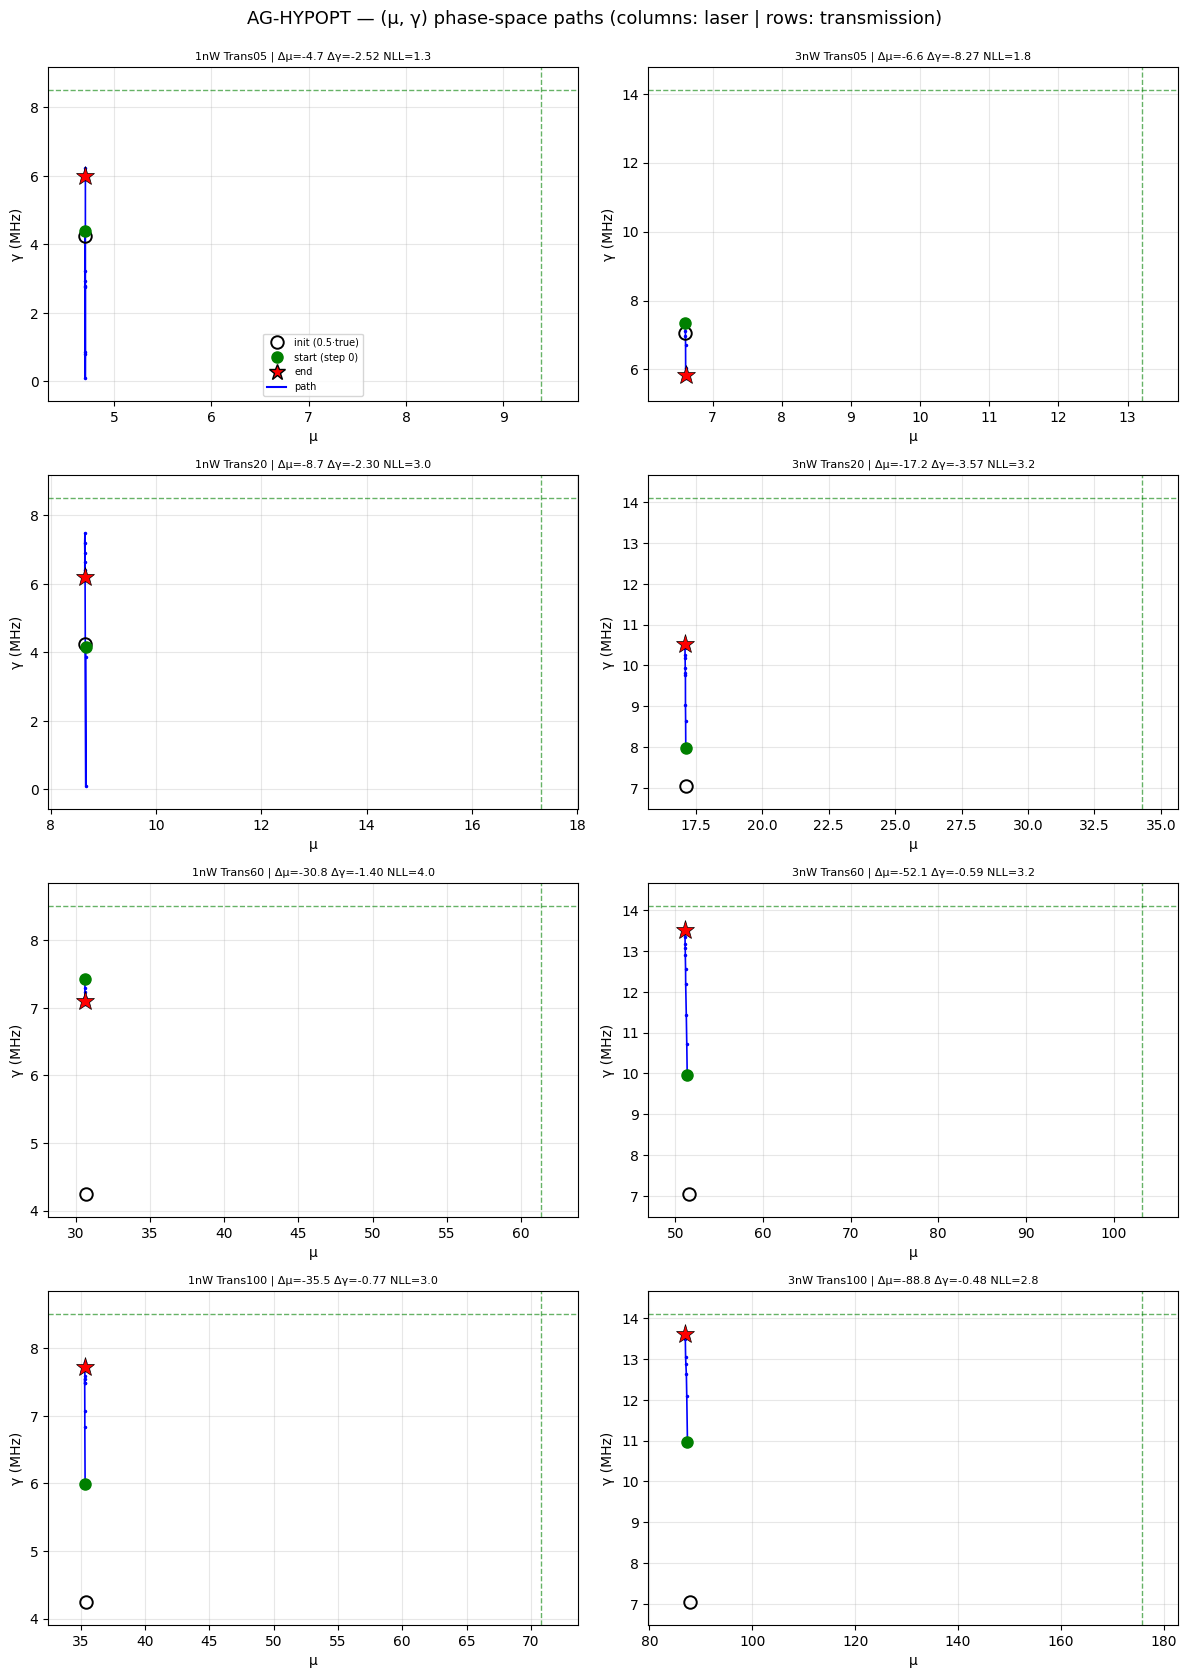

trial finished in 2.4 min
objective = 0.1637 ± 0.0298
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    4.70   -49.9 |     8.50    5.98   -29.6
1nW Trans20    17.32    8.65   -50.1 |     8.50    6.20   -27.0
1nW Trans60    61.37   30.62   -50.1 |     8.50    7.10   -16.4
1nW Trans100   70.82   35.33   -50.1 |     8.50    7.73    -9.1
3nW Trans05    13.20    6.62   -49.9 |    14.10    5.83   -58.6
3nW Trans20    34.28   17.10   -50.1 |    14.10   10.53   -25.3
3nW Trans60   103.20   51.12   -50.5 |    14.10   13.51    -4.2
3nW Trans100  175.71   86.92   -50.5 |    14.10   13.62    -3.4

μ: RMSE 40.677 (rel 50.2%, bias -30.530) | γ: RMSE 3.461 (rel 27.5%, bias -2.485)


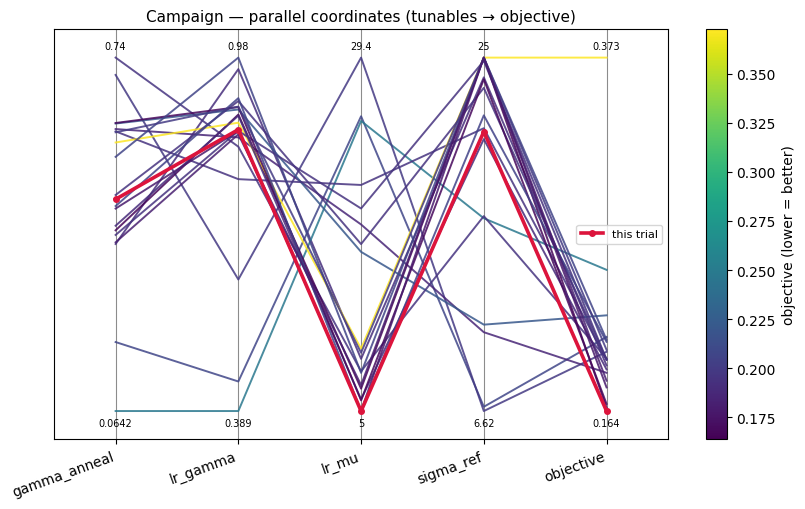

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 20, fifteenth TPE-driven trial and the FINAL trial of the campaign; highest-EI pick, in the sweet spot: sigma_ref 21.15, lr_mu 5.0, lr_gamma 0.859, gamma_anneal 0.469. Result: objective 0.1637 +/- 0.0298 -- the NEW campaign best, narrowly beating trial_09 (0.1657); runtime 2.4 min. mu_fit is unchanged at a uniform ~half-truth (Delta-mu% -49.9 to -50.5; mu RMSE 40.68, relative 50.2%). gamma_fit is the best of the campaign: RMSE 3.46 (relative 27.5%), with the low-transmission gate substantially improved -- 1 nW Trans05 -29.6% and 1 nW Trans20 -27.0% (versus the usual -50..-90%), 3 nW Trans05 -58.6%, and high transmission near-truth (3 nW Trans60/100: -4.2/-3.4%; 1 nW Trans100 -9.1%). So the sweet-spot recipe closed the campaign with both the lowest objective and the best gamma recovery.

**Summary:** Trial 20 (sigma_ref 21.15, lr_mu 5.0, lr_gamma 0.859, gamma_anneal 0.469) -> objective 0.1637 +/- 0.0298, NEW campaign best and best gamma RMSE (27.5%), with 1 nW Trans05/20 rescued to -30%/-27%.
**Key insight:** The final sweet-spot draw gave the campaign optimum: low lr_mu with high sigma_ref and high lr_gamma improves the low-transmission gamma that dominates the objective, while mu stays pinned at the invariant ~half-truth attractor.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
Notes for Anuar (structural, not acted on): across all 20 trials mu_fit stayed at ~50% of mu_true (context 7.7 real-data attractor), independent of the four hyperparameters -- this is a model/data-mismatch signature, so the mu half-truth gap almost certainly needs a structural fix (e.g. the pseudo-Voigt simulator of context 7.6) rather than hyperparameter tuning. The gamma term, by contrast, is tunable: sigma_ref ~21-25 with lr_mu ~5-7 and lr_gamma ~0.86-0.9 plus moderate anneal is the best region, and its residual error is the unstable Trans05 (low-count) gamma.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 20 (sigma_ref 21.15, lr_mu 5.0, lr_gamma 0.859, gamma_anneal 0.469): objective 0.1637 +/- 0.0298, NEW campaign best and best gamma RMSE (27.5%), with 1 nW Trans05/20 rescued to -30%/-27%'
KEY_INSIGHT = 'The final sweet-spot draw gave the campaign optimum: low lr_mu with high sigma_ref and high lr_gamma improves the objective-dominating low-transmission gamma, while mu stays pinned at an invariant ~half-truth attractor.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_20 | current best: trial_20


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Campaign complete: cap MAX_TRIALS=20 reached after trial_20. Stop here.
